# Assignment 1 — From Color to Structure: A Computer Vision Pipeline
## Name: Mayar Waleed Nawas  
GitHub repository Link: https://github.com/myarnwas/SKillStack-Paths-Neural-Networks-and-Computer-Vision 

### 1. Load and Display a Color Image

In [69]:
# use Pillow
from PIL import Image
img_Pillow = Image.open("./data/Home.jpeg")
print(img_Pillow.size, img_Pillow.mode) # (width, height), and mode like 'RGB'
print(img_Pillow.getbands()) # ('R', 'G', 'B')
print("===============================================") 
# use open cv
import cv2
img_open_cv = cv2.imread("./data/Home.jpeg")
print(img_open_cv.shape) # (height, width, channels)

(576, 597) RGB
('R', 'G', 'B')
(597, 576, 3)


### Q1
1. What is the shape of the image?  (height = 597, width = 576, channels = 3)  
- the code is img_open_cv.shape use Open_cv, and in Pillow (width, height)
2. What do the channels represent?  channels = 3 -> ('R' red, 'G' green, 'B' blue)

### 2. Convert to Grayscale

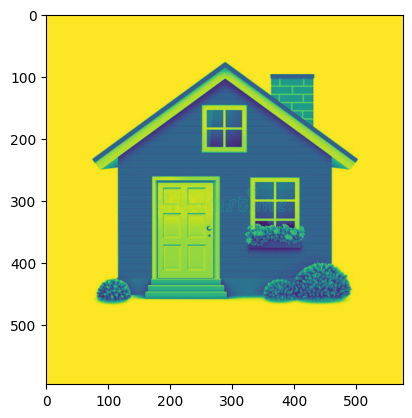

In [70]:
# i need use just open cv
img_BGR = cv2.cvtColor(img_open_cv, cv2.COLOR_BGR2GRAY)
import matplotlib.pyplot as plt 
%matplotlib inline 
plt.imshow(img_BGR) # GBR

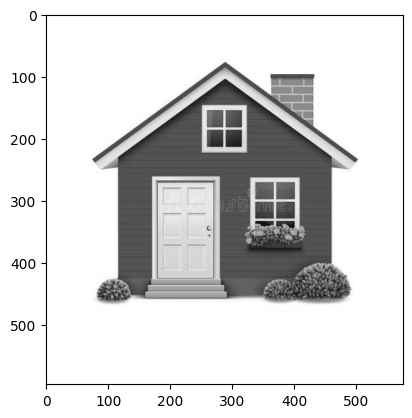

In [71]:
img_grey = cv2.cvtColor(img_open_cv, cv2.COLOR_BGR2GRAY)
plt.imshow(img_grey, cmap='grey')

### Q2
1. What changed compared to the original image?  
the image become grey without color
2. What information is preserved and what is lost?  
(576, 597) , lost channel

### 3. Noise Reduction (Smoothing)

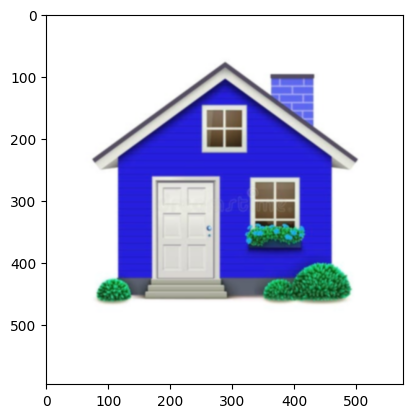

In [72]:
# Apply a smoothing filter 
Gaussian_filter_blurred_RGB = cv2.GaussianBlur(img_open_cv, (5, 5), 0)
# Display the smoothed image in RGB
plt.imshow(Gaussian_filter_blurred_RGB) # RGB

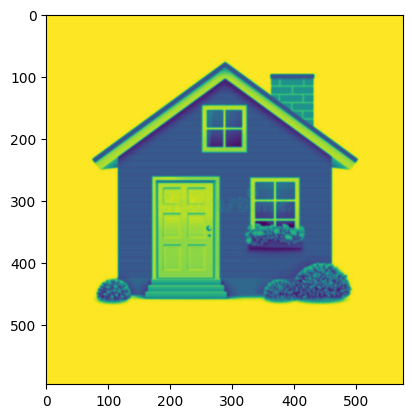

In [73]:
# Apply a smoothing filter 
Gaussian_filter_blurred_GBR = cv2.GaussianBlur(img_BGR, (5, 5), 0)
# Display the smoothed image in GBR
plt.imshow(Gaussian_filter_blurred_GBR) # GBR

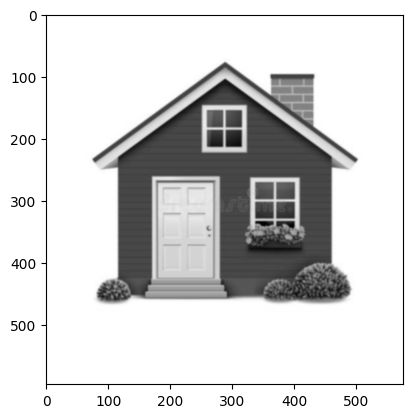

In [74]:
# Apply a smoothing filter 
Gaussian_filter_blurred = cv2.GaussianBlur(img_grey, (5, 5), 0)
# Display the smoothed image in grayscale
plt.imshow(Gaussian_filter_blurred, cmap='gray')

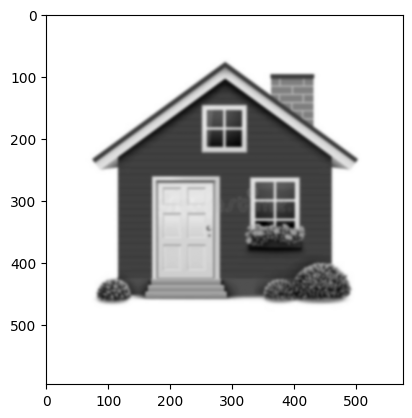

In [75]:
# More Blur
# Apply a smoothing filter 
Gaussian_filter_blurred_more = cv2.GaussianBlur(img_grey, (11, 11), 0) # must this be odd number => (11, 11)
# Display the smoothed image in grayscale
plt.imshow(Gaussian_filter_blurred_more, cmap='gray')

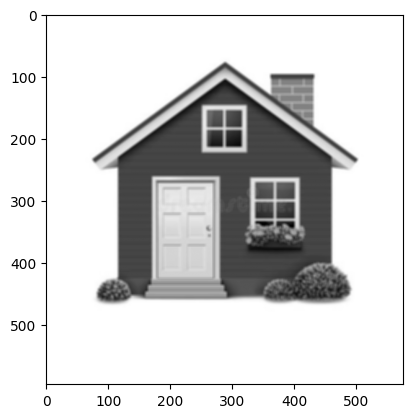

In [76]:
# More Blur
# Apply a smoothing filter 
Gaussian_filter_blurred_more = cv2.GaussianBlur(img_grey, (5, 5), 5)
# Display the smoothed image in grayscale
plt.imshow(Gaussian_filter_blurred_more, cmap='gray')

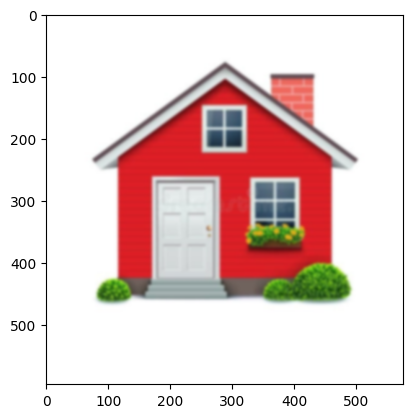

In [77]:
# another way to blur in Pillow
from PIL import ImageFilter
# Radius 2 blur
blurred_img = img_Pillow.filter(ImageFilter.GaussianBlur(radius=2)) # radius=20 more blur
plt.imshow(blurred_img)


### Q3
1. Why do we apply smoothing before edge detection?  
to reduce noise
2. What visual changes do you observe?  
image is blur and more smooth

### 4. Edge Detection
##### i want use Canny cuz in lab we talk its better than Sobel 

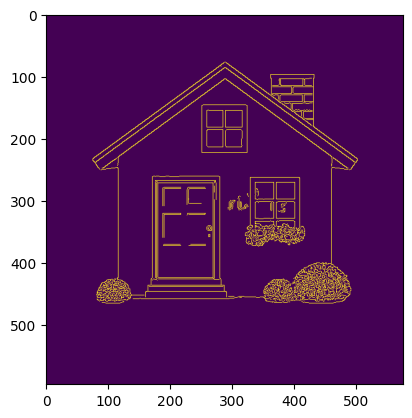

In [78]:
# in open cv
edgesg_BGR = cv2.Canny(img_BGR, 100, 200) # Detects edges using double thresholding
plt.imshow(edgesg_BGR)
# Note: in Pillow can not use Canny edge detection, but can use other edge detection methods like FIND_EDGES

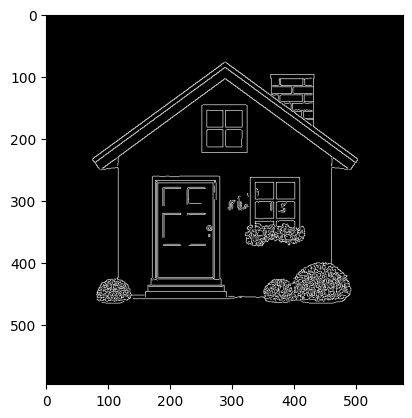

In [79]:
# in gray scale
edges = cv2.Canny(img_grey, 100, 200) # Detects edges using double thresholding
plt.imshow(edges, cmap='gray')

### Q4
1. What do the edges represent?  
diffrent region (intensity change)

### 5. From Edges to Structure

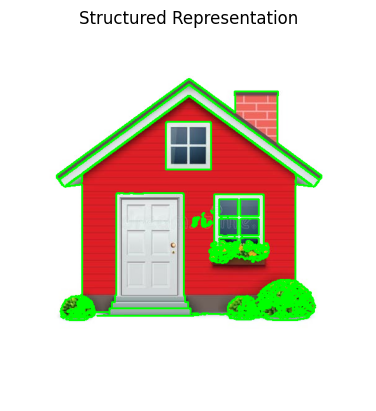

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Extract contours (they represent the structure)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on a copy of the original image
structured = np.array(img_open_cv)
cv2.drawContours(structured, contours, -1, (0, 255, 0), 2) #-1 => All contours, (0, 255, 0) => color is green, 2 => thickness

# عرض النتائج
plt.title("Structured Representation")
plt.imshow(cv2.cvtColor(structured, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

### Q5
1. What information is missing compared to the original image?  
missing: color, texture, and lighting details  
only preserves structural information such as shapes and boundaries